In [ ]:
import pandas as pd

df = pd.read_csv("../data/E0 (0).csv")
df.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,11/08/2023,20:00,Burnley,Man City,0,3,A,0,2,...,2.28,1.50,1.95,1.98,1.95,1.97,NaN,NaN,1.92,1.95
1,E0,12/08/2023,12:30,Arsenal,Nott'm Forest,2,1,H,2,0,...,2.63,-2.00,1.95,1.98,1.93,1.97,2.01,2.09,1.95,1.92
2,E0,12/08/2023,15:00,Bournemouth,West Ham,1,1,D,0,0,...,2.12,0.00,2.02,1.91,2.01,1.92,2.06,1.96,1.96,1.91
3,E0,12/08/2023,15:00,Brighton,Luton,4,1,H,1,0,...,2.48,-1.75,2.01,1.92,2.00,1.91,2.14,1.93,2.00,1.86
4,E0,12/08/2023,15:00,Everton,Fulham,0,1,A,0,0,...,1.71,-0.25,2.06,1.87,2.04,1.88,2.08,1.99,1.98,1.88


In [4]:
df.shape

(380, 68)

In [5]:
df.columns

Index(['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG',
       'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC',
       'AC', 'HY', 'AY', 'HR', 'AR', 'B365H', 'B365D', 'B365A', 'BWH', 'BWD',
       'BWA', 'IWH', 'IWD', 'IWA', 'LBH', 'LBD', 'LBA', 'PSH', 'PSD', 'PSA',
       'WHH', 'WHD', 'WHA', 'SJH', 'SJD', 'SJA', 'VCH', 'VCD', 'VCA', 'Bb1X2',
       'BbMxH', 'BbAvH', 'BbMxD', 'BbAvD', 'BbMxA', 'BbAvA', 'BbOU',
       'BbMx>2.5', 'BbAv>2.5', 'BbMx<2.5', 'BbAv<2.5', 'BbAH', 'BbAHh',
       'BbMxAHH', 'BbAvAHH', 'BbMxAHA', 'BbAvAHA', 'PSCH', 'PSCD', 'PSCA'],
      dtype='object')

In [6]:
df[['HomeTeam','AwayTeam','FTHG','FTAG','FTR']].head()

,HomeTeam,AwayTeam,FTHG,FTAG,FTR
0,Arsenal,Aston Villa,1,3,A
1,Liverpool,Stoke,1,0,H
2,Norwich,Everton,2,2,D
3,Sunderland,Fulham,0,1,A
4,Swansea,Man United,1,4,A


In [5]:
df['result'] = df['FTR'].map({'H': 1, 'D': 0, 'A': -1})
df['result'].value_counts()

result
 1    175
-1    123
 0     82
Name: count, dtype: int64

In [7]:
features = ['HS','AS','HST','AST','HC','AC']
x = df[features]
y = df['result']

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=72688
)

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.6710526315789473
[[26  0  8]
 [ 6  1  6]
 [ 5  0 24]]


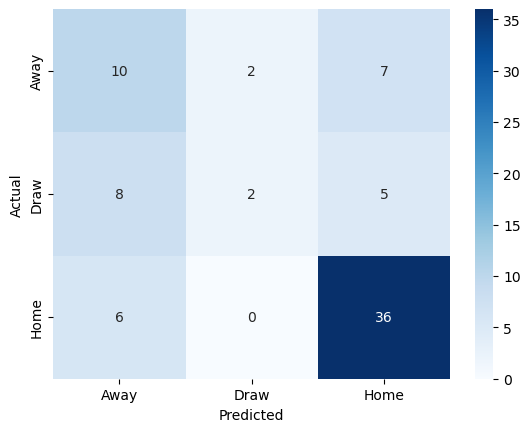

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['Away','Draw','Home'],
            yticklabels=['Away','Draw','Home'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X = df[['B365H','B365D','B365A']]   # pre-game odds
y = df['FTR']                       # 'H','D','A'

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred, labels=['H','D','A']))


Accuracy: 0.5921052631578947
[[25  0  6]
 [ 8  0  8]
 [ 9  0 20]]


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

df2 = df.dropna(subset=['Date','FTR','B365H','B365D','B365A']).copy()
df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=True, errors='coerce')
df2 = df2.dropna(subset=['Date']).sort_values('Date')

print("Date range:", df2['Date'].min(), "to", df2['Date'].max())

# choose a split that guarantees train/test both non-empty (80/20 by time)
split_date = df2['Date'].quantile(0.8)
print("Using split_date:", split_date)

X = 1 / df2[['B365H','B365D','B365A']]
X = X.div(X.sum(axis=1), axis=0)
y = df2['FTR']

train = df2['Date'] < split_date
test  = ~train

print("Train rows:", train.sum(), "Test rows:", test.sum())

model = LogisticRegression(max_iter=5000, class_weight='balanced')
model.fit(X[train], y[train])

pred = model.predict(X[test])
print("Accuracy:", accuracy_score(y[test], pred))
print(confusion_matrix(y[test], pred, labels=['H','D','A']))

Date range: 2023-08-11 00:00:00 to 2024-05-19 00:00:00
Using split_date: 2024-04-06 00:00:00
Train rows: 303 Test rows: 77
Accuracy: 0.6233766233766234
[[21  7  6]
 [ 3  5  6]
 [ 3  4 22]]


: 